# 10-day trader notebook — Refinitiv + current portfolio

## Trading thesis

This is a **simple tactical book** for the next 10 trading days:

**US Domestic Quality + Power + Oil Hedge**

The idea is:
- stop carrying the names that are already hurting the book and also sit in weak macro buckets,
- simplify the book toward **US-focused**, liquid names,
- keep a **defensive core** in utilities / staples / quality,
- keep one **oil-sensitive hedge**,
- remove the habit of averaging down weak cyclicals.

This notebook does four things:
1. loads your current open positions,
2. pulls **sector / country / industry** from Refinitiv,
3. builds a simple signal + risk triage,
4. prints a proposed **trade blotter** with target weights and comments.

The style is intentional: **simple is the edge**.


## Why this strategy

For a 10-day book, the priority is not long-term storytelling.  
The priority is:

- avoid the sectors currently doing the most damage,
- keep only names that deserve risk,
- size the book so one bad tape day does not wreck the whole portfolio.

So the portfolio becomes a **barbell**:

- **Defensive / resilient**: utilities, staples, quality healthcare-equipment style exposure
- **Opportunity / hedge**: one energy-linked name
- **Small cyclical sleeve only if momentum confirms**, never because the position is red


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import date, timedelta

plt.rcParams["figure.figsize"] = (11, 6)

CSV_PATH = Path("Open Positions Mar 8 2026.csv")
if not CSV_PATH.exists():
    CSV_PATH = Path("/mnt/data/Open Positions Mar 8 2026.csv")

df = pd.read_csv(CSV_PATH)

for col in ["Quantity", "LastPrice", "PricePaid", "DayChange", "MarketValue", "ProfitLossPercentage"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["ProfitLoss"] = (
    df["ProfitLoss"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.strip()
)
df["ProfitLoss"] = pd.to_numeric(df["ProfitLoss"], errors="coerce")

df["CostBasis"] = df["MarketValue"] - df["ProfitLoss"]
df["CurrentWeightPct"] = df["MarketValue"] / df["MarketValue"].sum() * 100

display(df)


,Symbol,Description,Quantity,Currency,LastPrice,PricePaid,DayChange,ProfitLoss,MarketValue,ProfitLossPercentage,CostBasis,CurrentWeightPct
0,AD,Agilent Technologies Inc.,130000,USD,49.03,48.17,-0.32,96283.86,5.489299e+06,1.79,5.393016e+06,9.020164
1,EIX,Edison International,100000,USD,71.76,73.85,0.54,-179993.97,6.180080e+06,-2.83,6.360074e+06,10.155273
2,FDX,Fedex Corp,20000,USD,359.10,382.79,-14.25,-408043.75,6.185247e+06,-6.19,6.593291e+06,10.163764
3,FTI,TechnipFMC plc,76000,USD,63.02,67.12,-1.42,-268354.65,4.124807e+06,-6.11,4.393162e+06,6.777994
4,GRMN,Garmin Ltd,23700,USD,243.48,250.00,3.31,-133078.41,4.969621e+06,-2.61,5.102700e+06,8.166215
5,HSY,Hershey Company,26927,USD,224.99,236.22,-1.59,-260423.04,5.217505e+06,-4.75,5.477928e+06,8.573544
6,HWM,Howmet Aerospace Inc,18000,USD,250.13,262.08,-2.26,-185247.38,3.877484e+06,-4.56,4.062731e+06,6.371585
7,MT,ARCELORMITTAL,120223,EUR,47.90,54.54,-1.41,-798280.72,5.758682e+06,-12.17,6.556962e+06,9.462820
8,OMC,"Omnicom Group, Inc.",70000,USD,84.93,85.01,0.16,-4822.80,5.120010e+06,-0.09,5.124833e+06,8.413338
9,PCG,PG&E Corp.,380000,USD,18.18,18.91,0.05,-238901.09,5.949619e+06,-3.86,6.188520e+06,9.776573


## Snapshot read

This is not a thesis notebook.  
This is a **P/L triage notebook**.

Questions to answer first:
- which names explain the drawdown,
- which sectors are weak,
- which losses are large enough that they should not stay in the book,
- which names can still earn capital in a volatile 10-day tape.


In [2]:
summary = pd.DataFrame({
    "Metric": [
        "Number of positions",
        "Total market value",
        "Total P/L",
        "Portfolio return %",
        "Winning positions",
        "Losing positions",
        "Top 3 weight %",
    ],
    "Value": [
        len(df),
        df["MarketValue"].sum(),
        df["ProfitLoss"].sum(),
        df["ProfitLoss"].sum() / df["CostBasis"].sum() * 100,
        int((df["ProfitLoss"] > 0).sum()),
        int((df["ProfitLoss"] < 0).sum()),
        df["CurrentWeightPct"].nlargest(3).sum(),
    ]
})

display(summary)

display(
    df[["Symbol", "Description", "MarketValue", "CurrentWeightPct", "ProfitLoss", "ProfitLossPercentage"]]
    .sort_values("ProfitLoss")
)


,Metric,Value
0,Number of positions,1.300000e+01
1,Total market value,6.085587e+07
2,Total P/L,-3.086344e+06
3,Portfolio return %,-4.826770e+00
4,Winning positions,2.000000e+00
5,Losing positions,1.100000e+01
6,Top 3 weight %,3.009561e+01


,Symbol,Description,MarketValue,CurrentWeightPct,ProfitLoss,ProfitLossPercentage
7,MT,ARCELORMITTAL,5.758682e+06,9.462820,-798280.72,-12.17
10,SCCO,Southern Copper Corporation,2.867381e+06,4.711758,-547681.18,-16.04
2,FDX,Fedex Corp,6.185247e+06,10.163764,-408043.75,-6.19
3,FTI,TechnipFMC plc,4.124807e+06,6.777994,-268354.65,-6.11
5,HSY,Hershey Company,5.217505e+06,8.573544,-260423.04,-4.75
9,PCG,PG&E Corp.,5.949619e+06,9.776573,-238901.09,-3.86
6,HWM,Howmet Aerospace Inc,3.877484e+06,6.371585,-185247.38,-4.56
1,EIX,Edison International,6.180080e+06,10.155273,-179993.97,-2.83
12,TPR,Tapestry Inc,2.855316e+06,4.691932,-179460.02,-5.91
4,GRMN,Garmin Ltd,4.969621e+06,8.166215,-133078.41,-2.61


## Refinitiv setup

This notebook is designed to use `refinitiv.data` directly.  
If your environment uses the newer library, you can switch to `lseg.data` with minimal edits.

The mapping below is intentionally explicit.  
For trading work, I prefer a **verified RIC map** over fully automatic name resolution, especially when broker/export descriptions are messy.


In [3]:
# Uncomment this in your own environment
import refinitiv.data as rd
rd.open_session()

RIC_MAP = {
    "AD": "A.N",          # Agilent Technologies
    "EIX": "EIX.N",
    "FDX": "FDX.N",
    "FTI": "FTI.N",
    "GRMN": "GRMN.N",
    "HSY": "HSY.N",
    "HWM": "HWM.N",
    "MT": "MT.N",         # US-listed line; adjust to your preferred listing if needed
    "OMC": "OMC.N",
    "PCG": "PCG.N",
    "SCCO": "SCCO.N",
    "TPL": "TPL.N",
    "TPR": "TPR.N",
}

BENCHMARK_RIC = "SPY.P"   # if this fails in your setup, replace with your preferred S&P 500 ETF RIC
LOOKBACK_DAYS = 120


## Refinitiv metadata pull

This fetches:
- common name,
- headquarters country,
- TRBC sector,
- TRBC business sector,
- TRBC industry group,
- TRBC industry.

These are enough to build a clean sector view and a country filter.


In [4]:
# Uncomment this block in your own environment
meta = rd.get_data(
    universe=list(RIC_MAP.values()),
    fields=[
        "TR.CommonName",
        "TR.HeadquartersCountry",
        "TR.TRBCEconomicSector",
        "TR.TRBCBusinessSector",
        "TR.TRBCIndustryGroup",
        "TR.TRBCIndustry",
    ],
)

display(meta)


,Instrument,Company Common Name,Country of Headquarters,TRBC Economic Sector Name,TRBC Business Sector Name,TRBC Industry Group Name,TRBC Industry Name
0,A.N,Agilent Technologies Inc,United States of America,Healthcare,Healthcare Services & Equipment,Healthcare Equipment & Supplies,Advanced Medical Equipment & Technology
1,EIX.N,Edison International,United States of America,Utilities,Utilities,Electric Utilities & IPPs,Electric Utilities
2,FDX.N,FedEx Corp,United States of America,Industrials,Transportation,Freight & Logistics Services,"Courier, Postal, Air Freight & Land-based Logi..."
3,FTI.N,TechnipFMC PLC,United Kingdom,Energy,Energy - Fossil Fuels,Oil & Gas Related Equipment and Services,Oil Related Services and Equipment
4,GRMN.N,Garmin Ltd,Switzerland,Technology,Technology Equipment,Communications & Networking,Communications & Networking
5,HSY.N,Hershey Co,United States of America,Consumer Non-Cyclicals,Food & Beverages,Food & Tobacco,Food Processing
6,HWM.N,Howmet Aerospace Inc,United States of America,Industrials,Industrial Goods,Aerospace & Defense,Aerospace & Defense
7,MT.N,ArcelorMittal SA,Luxembourg,Basic Materials,Mineral Resources,Metals & Mining,Iron & Steel
8,OMC.N,Omnicom Group Inc,United States of America,Consumer Cyclicals,Cyclical Consumer Services,Media & Publishing,Advertising & Marketing
9,PCG.N,PG&E Corp,United States of America,Utilities,Utilities,Electric Utilities & IPPs,Electric Utilities


## Fallback sector map

This fallback keeps the notebook usable even before the Refinitiv pull is fully wired.  
Once the Refinitiv metadata is available, replace these with the live TRBC fields.


In [5]:
MANUAL_SECTOR = {
    "AD": "Health Care",
    "EIX": "Utilities",
    "FDX": "Industrials - Transportation",
    "FTI": "Energy Equipment & Services",
    "GRMN": "Technology / Electronics",
    "HSY": "Consumer Staples",
    "HWM": "Industrials - Aerospace",
    "MT": "Materials - Steel",
    "OMC": "Communication Services",
    "PCG": "Utilities",
    "SCCO": "Materials - Copper",
    "TPL": "Energy / Royalty",
    "TPR": "Consumer Discretionary",
}

MANUAL_COUNTRY = {
    "AD": "United States",
    "EIX": "United States",
    "FDX": "United States",
    "FTI": "United Kingdom",
    "GRMN": "Switzerland",
    "HSY": "United States",
    "HWM": "United States",
    "MT": "Luxembourg",
    "OMC": "United States",
    "PCG": "United States",
    "SCCO": "United States",
    "TPL": "United States",
    "TPR": "United States",
}

df["SectorFallback"] = df["Symbol"].map(MANUAL_SECTOR)
df["HQCountryFallback"] = df["Symbol"].map(MANUAL_COUNTRY)

display(df[["Symbol", "Description", "SectorFallback", "HQCountryFallback"]])


,Symbol,Description,SectorFallback,HQCountryFallback
0,AD,Agilent Technologies Inc.,Health Care,United States
1,EIX,Edison International,Utilities,United States
2,FDX,Fedex Corp,Industrials - Transportation,United States
3,FTI,TechnipFMC plc,Energy Equipment & Services,United Kingdom
4,GRMN,Garmin Ltd,Technology / Electronics,Switzerland
5,HSY,Hershey Company,Consumer Staples,United States
6,HWM,Howmet Aerospace Inc,Industrials - Aerospace,United States
7,MT,ARCELORMITTAL,Materials - Steel,Luxembourg
8,OMC,"Omnicom Group, Inc.",Communication Services,United States
9,PCG,PG&E Corp.,Utilities,United States


## Historical price pull from Refinitiv

This section pulls daily closes and builds simple tactical metrics:

- 5-day momentum
- 20-day momentum
- 20-day realized volatility
- 20-day drawdown
- simple beta to SPY

That is enough for a 10-day tactical process.


In [13]:
from datetime import date, timedelta
import pandas as pd
import numpy as np

start_date = (date.today() - timedelta(days=LOOKBACK_DAYS)).isoformat()
end_date = date.today().isoformat()


def fetch_close_series(ric, start_date, end_date, debug=False):
    # Cách ổn nhất với rd.get_history: gọi trước không chỉ định fields
    hist = rd.get_history(
        universe=ric,
        interval="daily",
        start=start_date,
        end=end_date,
    )

    if hist is None or hist.empty:
        raise ValueError(f"No history returned for {ric}")

    if debug:
        print(f"\n=== {ric} raw output ===")
        print(type(hist))
        print("index:", hist.index.names)
        print("columns:", list(hist.columns))
        print(hist.head())

    # Nếu trả về Series thì convert luôn
    if isinstance(hist, pd.Series):
        s = hist.copy()
        s.name = ric
        s.index = pd.to_datetime(s.index)
        return s.sort_index()

    # Nếu là DataFrame thì reset index để tìm cột ngày
    hist = hist.copy().reset_index()
    hist.columns = [str(c) for c in hist.columns]

    if debug:
        print(f"{ric} after reset columns:", hist.columns.tolist())

    # 1) tìm cột ngày
    date_candidates = [c for c in hist.columns if "date" in c.lower()]
    if not date_candidates:
        # fallback: nếu index cũ đã thành cột đầu tiên
        date_col = hist.columns[0]
    else:
        date_col = date_candidates[0]

    # 2) tìm cột giá ưu tiên
    preferred_patterns = [
        "close",
        "trdprc_1",
        "price close",
        "priceclose",
        "trade price",
    ]

    price_col = None
    for c in hist.columns:
        cl = c.lower()
        if any(p in cl for p in preferred_patterns):
            if c != date_col:
                price_col = c
                break

    # 3) fallback: lấy cột numeric cuối cùng
    if price_col is None:
        numeric_cols = hist.select_dtypes(include=[np.number]).columns.tolist()
        numeric_cols = [c for c in numeric_cols if c != date_col]
        if not numeric_cols:
            raise ValueError(f"{ric}: cannot identify price column. Columns={hist.columns.tolist()}")
        price_col = numeric_cols[-1]

    out = hist[[date_col, price_col]].copy()
    out.columns = ["Date", ric]
    out["Date"] = pd.to_datetime(out["Date"], errors="coerce")
    out = out.dropna(subset=["Date", ric]).sort_values("Date")

    return out.set_index("Date")[ric]


series_list = []

for sym, ric in {**RIC_MAP, "_BENCH_": BENCHMARK_RIC}.items():
    try:
        s = fetch_close_series(ric, start_date, end_date, debug=False)
        series_list.append(s.rename(ric))
        print(f"OK: {ric} -> {len(s)} rows")
    except Exception as e:
        print(f"Failed: {ric} -> {e}")

if not series_list:
    raise ValueError("No series fetched. Check session / entitlements / RICs.")

close_wide = pd.concat(series_list, axis=1).sort_index().ffill().dropna(how="all")
display(close_wide.tail())

OK: A.N -> 80 rows
OK: EIX.N -> 80 rows
OK: FDX.N -> 80 rows
OK: FTI.N -> 80 rows


/opt/anaconda3/envs/final_project/lib/python3.12/site-packages/refinitiv/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


OK: GRMN.N -> 80 rows
OK: HSY.N -> 80 rows
OK: HWM.N -> 80 rows
OK: MT.N -> 80 rows
OK: OMC.N -> 80 rows
OK: PCG.N -> 80 rows
OK: SCCO.N -> 80 rows


/opt/anaconda3/envs/final_project/lib/python3.12/site-packages/refinitiv/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


OK: TPL.N -> 80 rows
OK: TPR.N -> 80 rows
OK: SPY.P -> 80 rows


,A.N,EIX.N,FDX.N,FTI.N,GRMN.N,HSY.N,HWM.N,MT.N,OMC.N,PCG.N,SCCO.N,TPL.N,TPR.N,SPY.P
Date,,,,,,,,,,,,,,
2026-03-02,118.17,74.42,387.25,67.5,255.16,235.69,265.11,64.5,85.36,19.11,218.85,531.09,156.42,686.38
2026-03-03,119.04,73.86,382.53,66.13,250.69,234.16,258.84,60.07,84.62,18.92,206.23,523.64,154.42,680.33
2026-03-04,120.54,73.89,384.09,65.27,251.18,232.05,260.09,61.16,85.8,18.88,206.66,536.11,156.91,685.13
2026-03-05,118.11,71.22,373.35,64.44,240.17,226.58,252.39,57.44,84.77,18.13,191.87,523.31,149.6,681.31
2026-03-06,115.07,71.76,359.1,63.02,243.48,224.99,250.13,55.4,84.93,18.18,184.97,525.03,144.15,672.38


In [14]:
# If you ran the historical price cell above, uncomment this block
returns = close_wide.pct_change()

def max_drawdown(x):
    roll_max = x.cummax()
    dd = x / roll_max - 1
    return dd.min()

stat_rows = []
bench_ret = returns[BENCHMARK_RIC].dropna()

for sym, ric in RIC_MAP.items():
    if ric not in close_wide.columns:
        continue
    px = close_wide[ric].dropna()
    ret = px.pct_change().dropna()

    mom_5 = px.iloc[-1] / px.iloc[-6] - 1 if len(px) >= 6 else np.nan
    mom_20 = px.iloc[-1] / px.iloc[-21] - 1 if len(px) >= 21 else np.nan
    vol_20 = ret.tail(20).std() * np.sqrt(252) if len(ret) >= 20 else np.nan
    dd_20 = max_drawdown(px.tail(20)) if len(px) >= 20 else np.nan

    aligned = pd.concat([ret, bench_ret], axis=1, join="inner").dropna()
    beta_20 = np.nan
    if len(aligned) >= 20:
        cov = np.cov(aligned.iloc[-20:, 0], aligned.iloc[-20:, 1])[0, 1]
        var = np.var(aligned.iloc[-20:, 1])
        beta_20 = cov / var if var != 0 else np.nan

    stat_rows.append({
        "Symbol": sym,
        "RIC": ric,
        "Mom5": mom_5,
        "Mom20": mom_20,
        "Vol20": vol_20,
        "DD20": dd_20,
        "Beta20": beta_20,
    })

signal_df = pd.DataFrame(stat_rows)
display(signal_df.sort_values("Mom20"))


,Symbol,RIC,Mom5,Mom20,Vol20,DD20,Beta20
0,AD,A.N,-0.051986,-0.112388,0.267224,-0.111977,0.614286
7,MT,MT.N,-0.149785,-0.032145,0.625265,-0.174613,3.379897
10,SCCO,SCCO.N,-0.152680,-0.015401,0.581308,-0.154809,2.850120
2,FDX,FDX.N,-0.072093,-0.013353,0.236403,-0.075628,0.891032
5,HSY,HSY.N,-0.047782,0.002719,0.237661,-0.052391,0.799189
12,TPR,TPR.N,-0.072811,0.006704,0.405374,-0.101813,2.588601
9,PCG,PCG.N,-0.043158,0.116708,0.254417,-0.051282,-0.088535
3,FTI,FTI.N,-0.049615,0.120356,0.299191,-0.066370,1.649594
1,EIX,EIX.N,-0.039872,0.126354,0.306028,-0.053429,-0.309026
6,HWM,HWM.N,-0.047233,0.193198,0.374280,-0.056505,0.900262


## Sector stance for the next 10 days

This is the actual trader view behind the book:

### Overweight / keep
- **Utilities**: defensive cash-flow profile, regulated earnings, better downside behavior in an inflation / oil-shock tape
- **Energy / royalty**: one direct oil-sensitive hedge is useful while energy prices stay elevated
- **Consumer staples**: not exciting, but useful ballast for a short volatile holding window
- **Quality healthcare-equipment / analytics style exposure**: good for lower macro-beta growth
- **Selected industrial quality**: only if not oversized and not breaking down

### Underweight / exit
- **Materials / metals / miners**: too much macro beta for this tape, and they are already hurting the book
- **Transportation**: fuel sensitivity plus weak current tape
- **Consumer discretionary laggards**: wrong place to force a rebound trade
- **Europe-linked positions**: remove them if the mandate is now US-focused


## Strategy constraints

These constraints are the whole point.  
They are there to stop the book from getting hit all at once again.

### Book construction
- Long-only
- US-focused only for this tactical book
- Core book = 7 names
- Tactical cash sleeve = 10%
- No Europe-linked names
- No materials / miners in the 10-day book

### Position sizing
- Max single-name weight = **14%**
- Top 3 names combined <= **42%**
- Top 5 names combined <= **65%**
- Sector caps:
  - Utilities <= **30%**
  - Energy <= **15%**
  - Health care <= **15%**
  - Consumer staples <= **15%**
  - Industrials <= **15%**
  - Communication services <= **12%**
  - Materials = **0%**
  - Consumer discretionary <= **0%** for this 10-day plan

### Entry / exit rules
- Never add to a name currently below **-5%** P/L unless 5-day and 20-day momentum both turn positive
- Hard stop from new target weight = **-6%**
- Once a name is up **+4%** from rebalance, switch to a **5% trailing stop**
- No averaging down
- Re-entry only after price confirmation, not because the position is cheaper


## Recommended book for the next 10 days

This is the simple version.  
It is not trying to own everything.  
It is trying to own the names that still deserve risk.

### Hard exits now
- `MT`
- `FTI`
- `GRMN`
- `SCCO`
- `FDX`
- `TPR`

### Core keep / add
- `AD`
- `EIX`
- `PCG`
- `HSY`
- `HWM`
- `TPL`
- `OMC`

### Tactical sleeve
- Keep **10%** in cash or deploy only into the **best 5-day and 20-day momentum name** among your US keeps, while still respecting the single-name cap.

This is not conservative.  
It is selective.


In [15]:
TARGET_WEIGHTS = {
    "AD": 13,
    "EIX": 14,
    "PCG": 14,
    "HSY": 12,
    "HWM": 12,
    "TPL": 14,
    "OMC": 11,
    "FDX": 0,
    "FTI": 0,
    "GRMN": 0,
    "MT": 0,
    "SCCO": 0,
    "TPR": 0,
}

TACTICAL_CASH_PCT = 10
assert sum(TARGET_WEIGHTS.values()) + TACTICAL_CASH_PCT == 100

df["TargetWeightPct"] = df["Symbol"].map(TARGET_WEIGHTS).fillna(0)
df["TargetValue"] = df["TargetWeightPct"] / 100 * df["MarketValue"].sum()
df["DeltaValue"] = df["TargetValue"] - df["MarketValue"]
df["SharesToTrade"] = np.round(df["DeltaValue"] / df["LastPrice"]).astype(int)

def action_comment(row):
    sym = row["Symbol"]
    sector = row["SectorFallback"]
    pnl = row["ProfitLossPercentage"]

    if sym in ["MT", "FTI", "GRMN"]:
        return "Exit: non-US / Europe-linked simplification"
    if sym in ["SCCO", "FDX", "TPR"]:
        return "Exit: weak sector + weak tape"
    if sym in ["EIX", "PCG"]:
        return "Keep/add: defensive utility ballast"
    if sym == "TPL":
        return "Keep/add: oil hedge"
    if sym == "HSY":
        return "Keep/add: staples ballast"
    if sym == "AD":
        return "Keep/add: quality lower-macro-beta exposure"
    if sym == "HWM":
        return "Keep small/add only if tape stabilizes"
    if sym == "OMC":
        return "Keep modestly sized"
    return "Review"

df["DeskComment"] = df.apply(action_comment, axis=1)

trade_blotter = df[[
    "Symbol", "Description", "SectorFallback", "HQCountryFallback",
    "CurrentWeightPct", "TargetWeightPct", "ProfitLossPercentage",
    "DeltaValue", "SharesToTrade", "DeskComment"
]].sort_values("TargetWeightPct", ascending=False)

display(trade_blotter)


,Symbol,Description,SectorFallback,HQCountryFallback,CurrentWeightPct,TargetWeightPct,ProfitLossPercentage,DeltaValue,SharesToTrade,DeskComment
1,EIX,Edison International,Utilities,United States,10.155273,14,-2.83,2.339742e+06,32605,Keep/add: defensive utility ballast
9,PCG,PG&E Corp.,Utilities,United States,9.776573,14,-3.86,2.570203e+06,141375,Keep/add: defensive utility ballast
11,TPL,Texas Pacific Land Corporation,Energy / Royalty,United States,3.715038,14,0.97,6.259003e+06,11921,Keep/add: oil hedge
0,AD,Agilent Technologies Inc.,Health Care,United States,9.020164,13,1.79,2.421964e+06,49398,Keep/add: quality lower-macro-beta exposure
5,HSY,Hershey Company,Consumer Staples,United States,8.573544,12,-4.75,2.085200e+06,9268,Keep/add: staples ballast
6,HWM,Howmet Aerospace Inc,Industrials - Aerospace,United States,6.371585,12,-4.56,3.425221e+06,13694,Keep small/add only if tape stabilizes
8,OMC,"Omnicom Group, Inc.",Communication Services,United States,8.413338,11,-0.09,1.574136e+06,18535,Keep modestly sized
2,FDX,Fedex Corp,Industrials - Transportation,United States,10.163764,0,-6.19,-6.185247e+06,-17224,Exit: weak sector + weak tape
3,FTI,TechnipFMC plc,Energy Equipment & Services,United Kingdom,6.777994,0,-6.11,-4.124807e+06,-65452,Exit: non-US / Europe-linked simplification
4,GRMN,Garmin Ltd,Technology / Electronics,Switzerland,8.166215,0,-2.61,-4.969621e+06,-20411,Exit: non-US / Europe-linked simplification


## Order logic

Interpret `SharesToTrade` like this:
- negative = sell
- positive = buy

Because this is a tactical 10-day book, the first job is **cleaning the left tail**.  
That means the sell list matters more than the buy list.


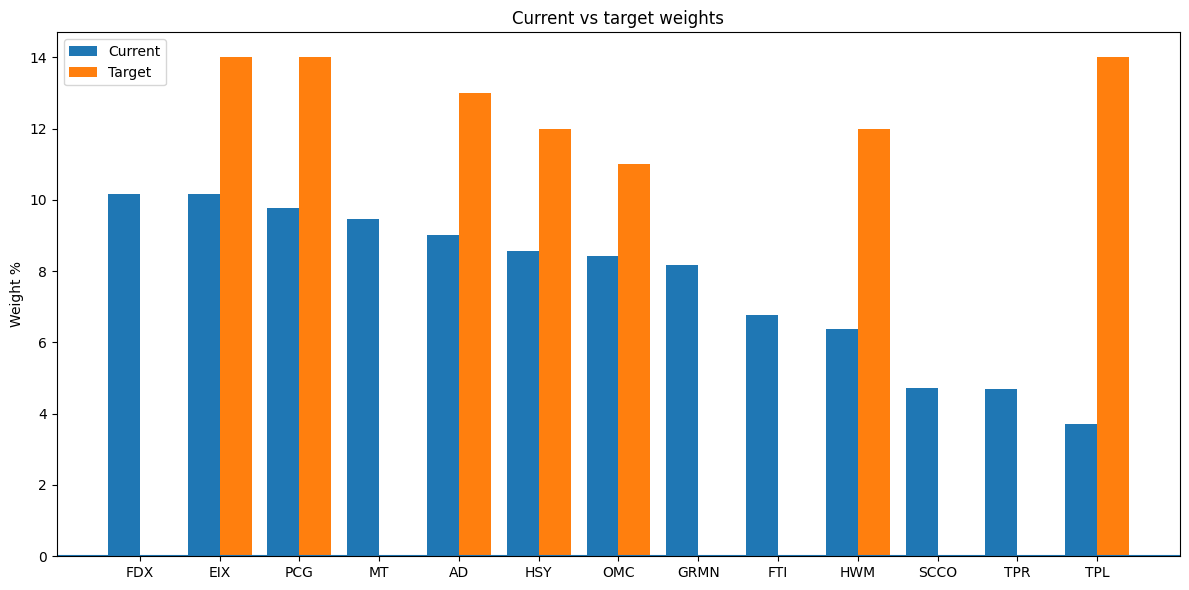

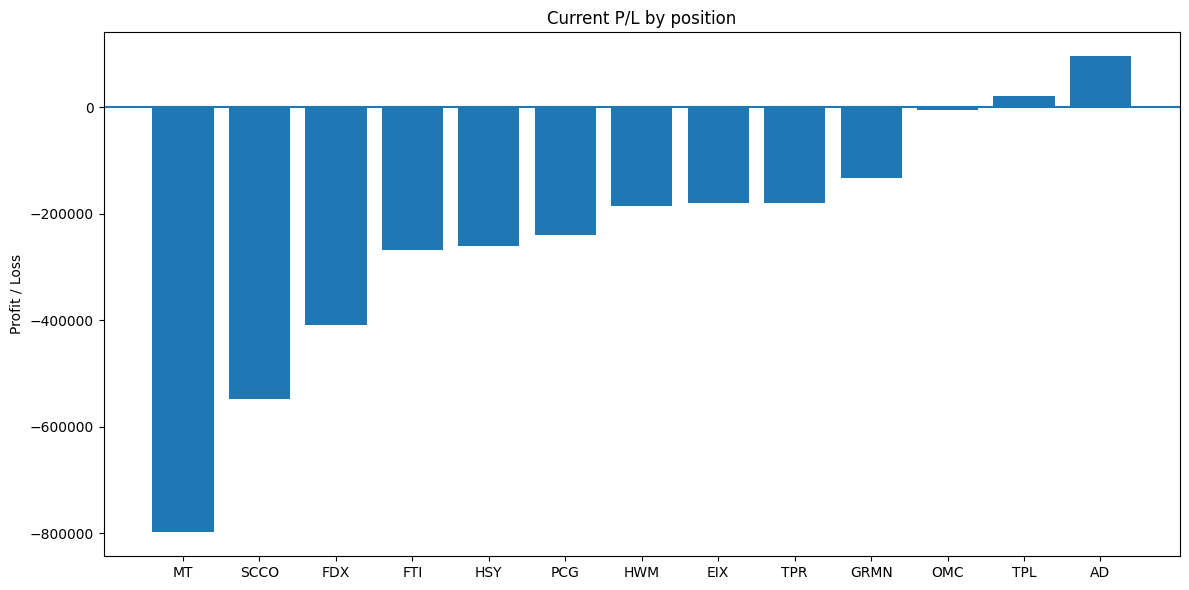

In [16]:
# Quick visual: current vs target weights
plot_df = df[["Symbol", "CurrentWeightPct", "TargetWeightPct"]].copy().sort_values("CurrentWeightPct", ascending=False)

x = np.arange(len(plot_df))
w = 0.4

plt.figure(figsize=(12, 6))
plt.bar(x - w/2, plot_df["CurrentWeightPct"], width=w, label="Current")
plt.bar(x + w/2, plot_df["TargetWeightPct"], width=w, label="Target")
plt.xticks(x, plot_df["Symbol"])
plt.axhline(0)
plt.title("Current vs target weights")
plt.ylabel("Weight %")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
tmp = df.sort_values("ProfitLoss")
plt.bar(tmp["Symbol"], tmp["ProfitLoss"])
plt.axhline(0)
plt.title("Current P/L by position")
plt.ylabel("Profit / Loss")
plt.tight_layout()
plt.show()


,CurrentWeightPct,TargetWeightPct
SectorFallback,,
Utilities,19.931847,28
Industrials - Transportation,10.163764,0
Materials - Steel,9.462820,0
Health Care,9.020164,13
Consumer Staples,8.573544,12
Communication Services,8.413338,11
Technology / Electronics,8.166215,0
Energy Equipment & Services,6.777994,0
Industrials - Aerospace,6.371585,12


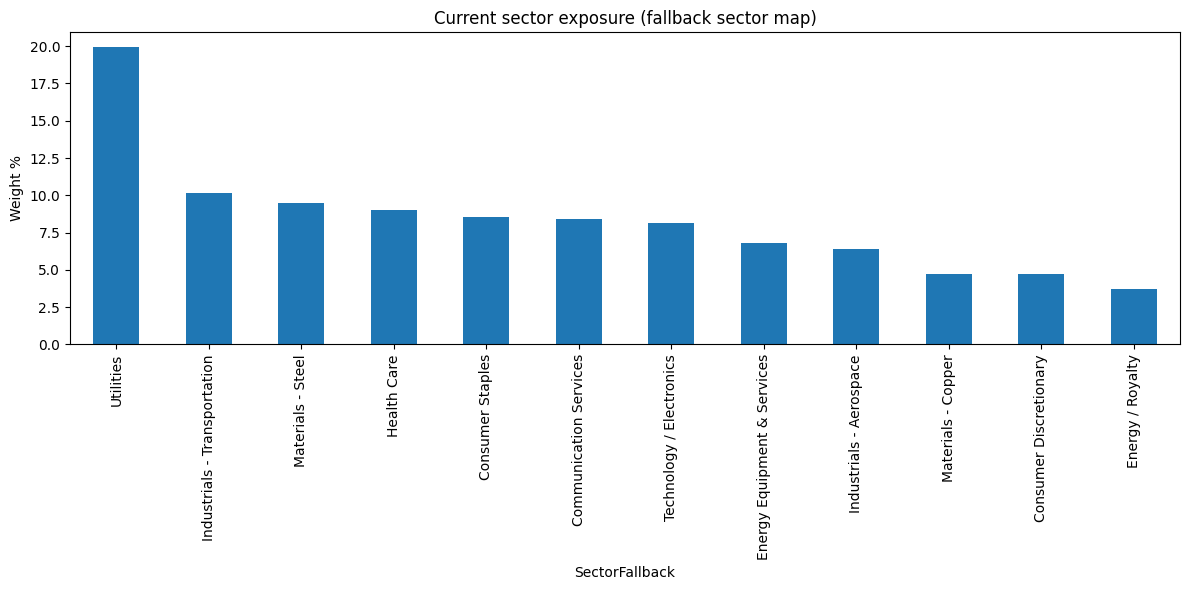

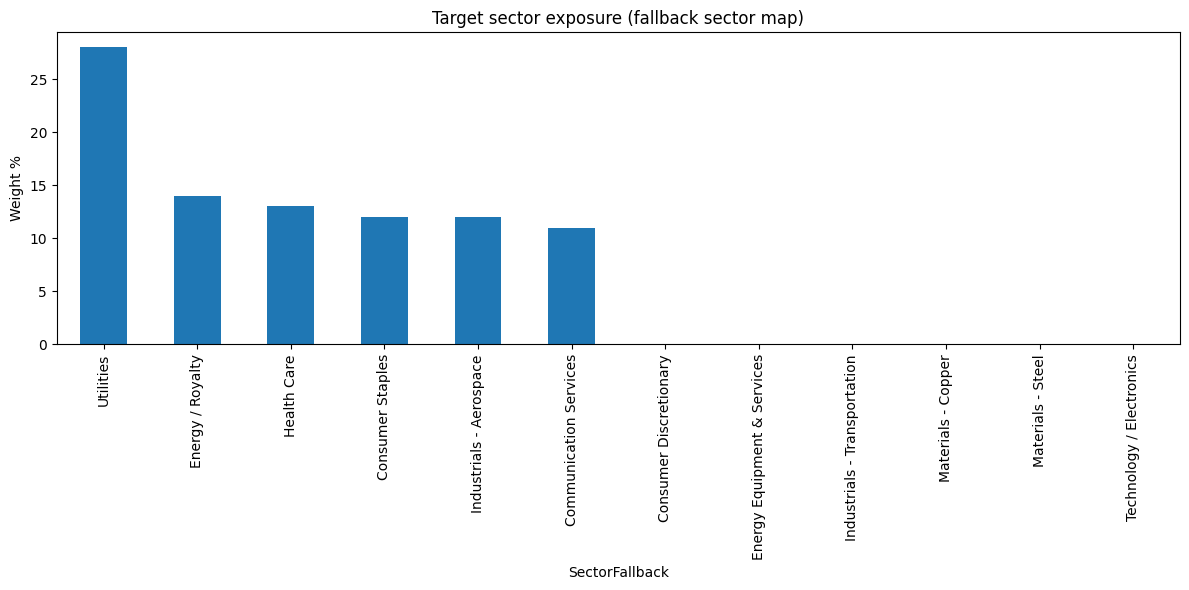

In [17]:
# Sector views: current book and target book
sector_current = df.groupby("SectorFallback")["CurrentWeightPct"].sum().sort_values(ascending=False)
sector_target = df.groupby("SectorFallback")["TargetWeightPct"].sum().sort_values(ascending=False)

display(pd.concat([sector_current.rename("CurrentWeightPct"), sector_target.rename("TargetWeightPct")], axis=1).fillna(0))

plt.figure(figsize=(12, 6))
sector_current.plot(kind="bar")
plt.title("Current sector exposure (fallback sector map)")
plt.ylabel("Weight %")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sector_target.plot(kind="bar")
plt.title("Target sector exposure (fallback sector map)")
plt.ylabel("Weight %")
plt.tight_layout()
plt.show()


## Two-step execution plan

### Day 0 - clean the book
Sell:
- `MT`
- `FTI`
- `GRMN`
- `SCCO`
- `FDX`
- `TPR`

Add toward:
- `EIX`
- `PCG`
- `TPL`
- `AD`
- `HSY`
- `HWM`
- `OMC`

### Day 4 or Day 5 - only if price confirms
Use the tactical 10% sleeve only if:
- 5-day momentum > 0
- 20-day momentum > 0
- price is above the 20-day moving average
- resulting weight still respects the 14% cap

If no name qualifies, keep the tactical sleeve in cash.


## Why each sector is treated this way

### Utilities - EIX, PCG
I want them because they reduce left-tail pain in a volatile tape.  
They are not the exciting leg. They are the **stability leg**.

### Energy / royalty - TPL
This is the simple macro hedge in the book.  
If oil stays elevated, I want one name that can offset pain elsewhere.

### Consumer staples - HSY
This is not a momentum monster.  
It is there because a short, noisy tape punishes lower-quality cyclical exposure faster than it punishes staples.

### Health care / quality tools - AD
This is a cleaner quality bucket than chasing a messy rebound in a deeply red cyclical.

### Industrials - HWM
This is the only cyclical-quality name I am willing to keep in size, and even here I want discipline.  
No aggressive averaging down.

### Communication services - OMC
Decent cash-flow profile, but not a sector to overweight heavily in this framework.

### Materials / steel / copper - MT, SCCO
These are the wrong risk right now for this book.  
Too much macro beta, too much drawdown contribution, not enough reason to keep.

### Transportation - FDX
Fuel-sensitive and already under pressure.  
Not where I want to press risk over the next 10 days.

### Consumer discretionary - TPR
No need to force a rebound in a weak discretionary name during a volatile tape.

### Europe-linked names - MT, FTI, GRMN
If the mandate now is US focus, keeping them just adds complexity and correlation you do not need.


## Optional: simple momentum overlay from Refinitiv history

If you run the historical price section, use this to top-up the best name with the 10% tactical sleeve.

Only deploy the sleeve when all conditions are true:
- `Mom5 > 0`
- `Mom20 > 0`
- `Vol20` not in the worst 30% of the book
- target weight after top-up <= 14%


In [18]:
# Example tactical sleeve logic after signal_df exists
signal_df = signal_df.merge(df[["Symbol", "TargetWeightPct"]], on="Symbol", how="left")
candidates = signal_df.query("Mom5 > 0 and Mom20 > 0").copy()
candidates = candidates.sort_values(["Mom20", "Mom5"], ascending=False)

if len(candidates):
    best = candidates.iloc[0]["Symbol"]
    print("Best tactical candidate:", best)
else:
    print("No tactical candidate. Keep the sleeve in cash.")


Best tactical candidate: TPL


## Bottom line

The mistake now would be to keep a wide red book and hope for a rebound.  
The cleaner trade is:

- simplify,
- cut the weak sectors,
- keep the defensive / quality sleeve,
- keep one oil hedge,
- only redeploy fresh risk into confirmed strength.

That is the whole strategy.
